In [2]:
!pip install plotnine

     ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
      --------------------------------------- 0.0/1.3 MB 1.3 MB/s eta 0:00:02
     - -------------------------------------- 0.1/1.3 MB 518.5 kB/s eta 0:00:03
     -- ------------------------------------- 0.1/1.3 MB 744.7 kB/s eta 0:00:02
     --- ------------------------------------ 0.1/1.3 MB 595.3 kB/s eta 0:00:03
     ---- ----------------------------------- 0.1/1.3 MB 652.5 kB/s eta 0:00:02
     ------ --------------------------------- 0.2/1.3 MB 808.4 kB/s eta 0:00:02
     -------- ------------------------------- 0.3/1.3 MB 944.1 kB/s eta 0:00:02
     -------- ------------------------------- 0.3/1.3 MB 944.1 kB/s eta 0:00:02
     -------------- ------------------------- 0.5/1.3 MB 1.1 MB/s eta 0:00:01
     --------------- ------------------------ 0.5/1.3 MB 1.1 MB/s eta 0:00:01
     ----------------- ---------------------- 0.6/1.3 MB 1.1 MB/s eta 0:00:01
     ------------------- -------------------- 0.6/1.3 MB 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [6]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

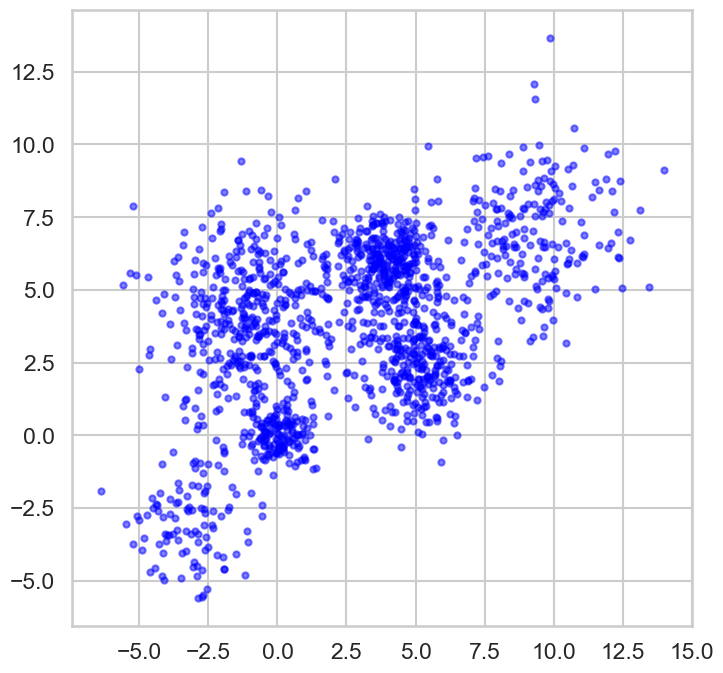

In [7]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

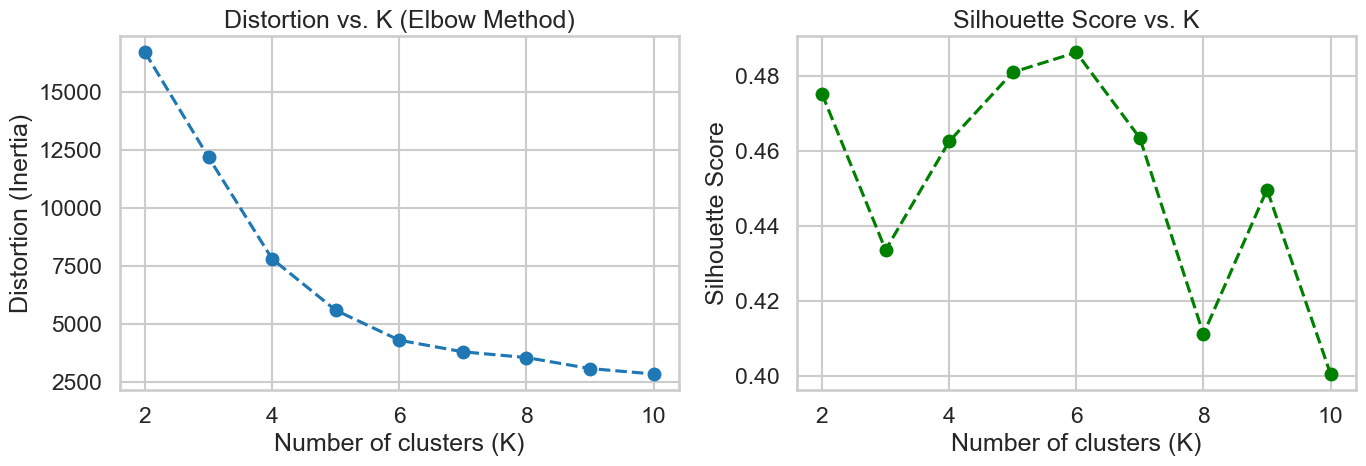

Stored Best K-Means Silhouette Score (K=6): 0.4862


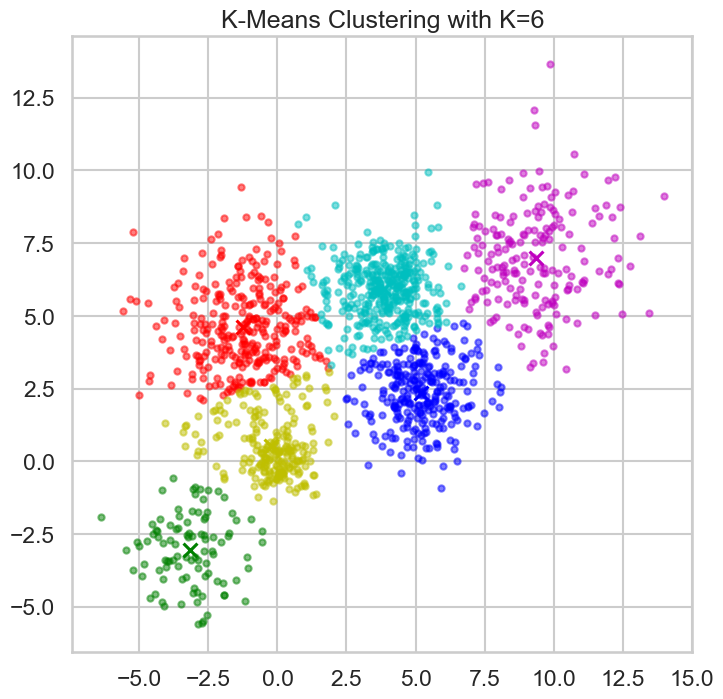

In [8]:
# ---------------------------------------------------------
# K-Means Clustering on Multi Blob Data
# ---------------------------------------------------------

# test K values from 2 to 10
k_values = range(2, 11)
distortions = []
silhouette_scores = []
kmeans_models = {}

for k in k_values:
    # Initialize KMeans
    # init='k-means++' which is the default ensuring smart centroid initialization
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(Multi_blob_Data)
    
    # Calculate and store distortion
    distortions.append(km.inertia_)
    
    # Calculate and store silhouette score
    sil_score = silhouette_score(Multi_blob_Data, km.labels_)
    silhouette_scores.append(sil_score)
    
    kmeans_models[k] = km

# --- Plotting ---
plt.figure(figsize=(14, 5))

# Plotting Distortion vs K (Elbow Method)
plt.subplot(1, 2, 1)
plt.plot(k_values, distortions, marker='o', linestyle='--')
plt.title('Distortion vs. K (Elbow Method)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Distortion (Inertia)')

# Plotting Silhouette Score vs K
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='green', linestyle='--')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# --- Visualizing the Best K ---
# Based on the data generation we know 6 is optimal
best_k = 6
best_km = kmeans_models[best_k]

best_sil_score_kmeans = silhouette_scores[k_values.index(best_k)]
print(f"Stored Best K-Means Silhouette Score (K={best_k}): {best_sil_score_kmeans:.4f}")

# Visualize the clusters using the provided helper function
plt.figure(figsize=(8, 8))
plt.title(f'K-Means Clustering with K={best_k}')
display_cluster(Multi_blob_Data, best_km, num_clusters=best_k)
plt.show()

In [ ]:

# Distortion and Silhouette Score: looking at the graphs, the distortion drops significantly and forms an elbow around K=6
# the silhouette score peaks at K=6 confirming that 6 is the optimal number of clusters

# Effect of centroid initialization: 
# randomly initializing centroids can lead to poor clustering because the algorithm might get stuck in a bad local minimum depending on where the initial points land
# using init='k-means++' solves this by initializing the centroids far away from each other
# This speeds up convergence and consistently yields much better cluster assignments

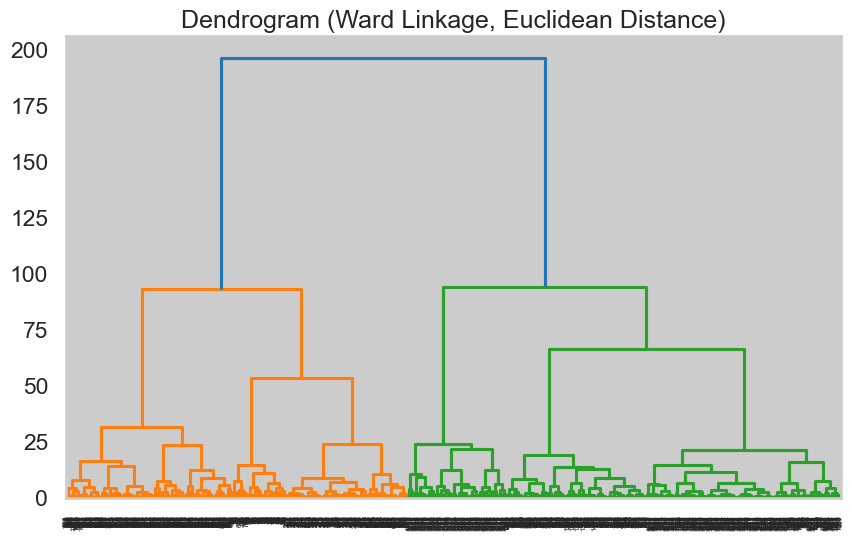

--- Testing Affinity and Linkage Combinations (n_clusters=6) ---
Affinity: euclidean, Linkage: ward -> Silhouette Score: 0.4687
Affinity: euclidean, Linkage: complete -> Silhouette Score: 0.3819
Affinity: euclidean, Linkage: average -> Silhouette Score: 0.4148
Affinity: euclidean, Linkage: single -> Silhouette Score: 0.0871
Affinity: manhattan, Linkage: complete -> Silhouette Score: 0.3370
Affinity: manhattan, Linkage: average -> Silhouette Score: 0.3803
Affinity: manhattan, Linkage: single -> Silhouette Score: 0.0871
Affinity: cosine, Linkage: complete -> Silhouette Score: 0.1885
Affinity: cosine, Linkage: average -> Silhouette Score: 0.2036
Affinity: cosine, Linkage: single -> Silhouette Score: 0.0716

Stored Best Agglomerative Silhouette Score: 0.4687 using {'affinity': 'euclidean', 'linkage': 'ward'}

--- Testing Distance Thresholds (n_clusters=None) ---
Threshold: 10 -> Found 27 clusters, Silhouette Score: 0.3264
Threshold: 20 -> Found 12 clusters, Silhouette Score: 0.3515
Thresho

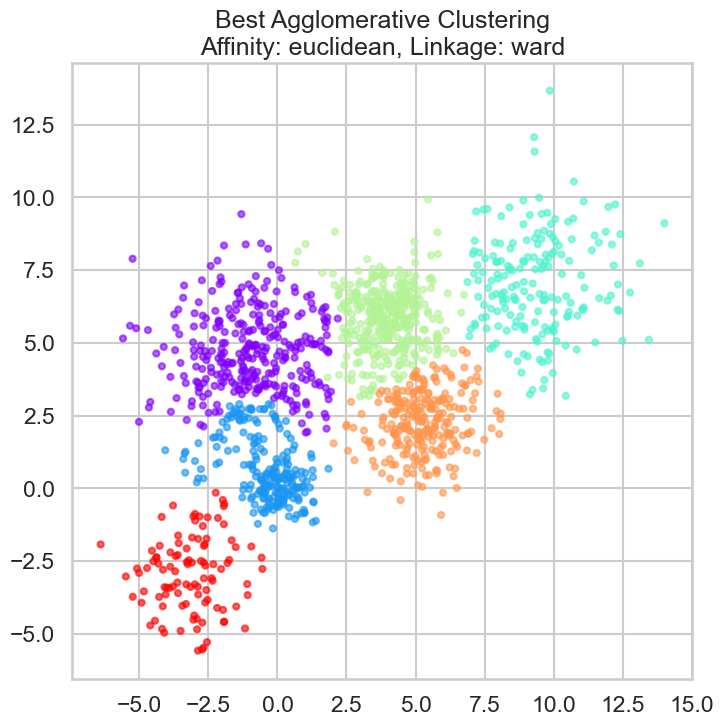

In [12]:
# ------------------------------------------------------
# Agglomerative Clustering on Multi Blob Data
# ------------------------------------------------------
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc

# --- Plotting the Dendrogram ---
plt.figure(figsize=(10, 6))
plt.title("Dendrogram (Ward Linkage, Euclidean Distance)")
dend = shc.dendrogram(shc.linkage(Multi_blob_Data, method='ward'))
plt.show()

# --- Testing Affinity and Linkage ---
affinities = ['euclidean', 'manhattan', 'cosine']
linkages = ['complete', 'average', 'single'] # ward is tested separately because it only works with 'euclidean'

best_sil_score_agglo = -1
best_params = {}
best_labels = None

print("--- Testing Affinity and Linkage Combinations (n_clusters=6) ---")

# Test ward linkage first (requires euclidean affinity)
agg_ward = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
labels_ward = agg_ward.fit_predict(Multi_blob_Data)
score_ward = silhouette_score(Multi_blob_Data, labels_ward)
print(f"Affinity: euclidean, Linkage: ward -> Silhouette Score: {score_ward:.4f}")

# Initialize best trackers
best_sil_score_agglo = score_ward
best_params = {'affinity': 'euclidean', 'linkage': 'ward'}
best_labels = labels_ward

# Loop through the rest of the combinations
for aff in affinities:
    for link in linkages:
        agg = AgglomerativeClustering(n_clusters=6, metric=aff, linkage=link)
        labels = agg.fit_predict(Multi_blob_Data)
        score = silhouette_score(Multi_blob_Data, labels)
        print(f"Affinity: {aff}, Linkage: {link} -> Silhouette Score: {score:.4f}")
        
        if score > best_sil_score_agglo:
            best_sil_score_agglo = score
            best_params = {'affinity': aff, 'linkage': link}
            best_labels = labels

print(f"\nStored Best Agglomerative Silhouette Score: {best_sil_score_agglo:.4f} using {best_params}")

# --- Testing Distance Thresholds ---
print("\n--- Testing Distance Thresholds (n_clusters=None) ---")

thresholds = [10, 20, 30, 35] 
for t in thresholds:
    # When using distance_threshold, n_clusters must be None
    agg_t = AgglomerativeClustering(n_clusters=None, distance_threshold=t, metric='euclidean', linkage='ward')
    labels_t = agg_t.fit_predict(Multi_blob_Data)
    
    num_clusters = len(np.unique(labels_t))
    # Silhouette score is only valid if we have more than 1 cluster, and fewer clusters than samples
    if 1 < num_clusters < len(Multi_blob_Data):
        score_t = silhouette_score(Multi_blob_Data, labels_t)
        print(f"Threshold: {t} -> Found {num_clusters} clusters, Silhouette Score: {score_t:.4f}")
    else:
        print(f"Threshold: {t} -> Found {num_clusters} clusters (Invalid for Silhouette)")

# --- Visualizing the Best Cluster Assignment ---
plt.figure(figsize=(8, 8))
plt.title(f"Best Agglomerative Clustering\nAffinity: {best_params['affinity']}, Linkage: {best_params['linkage']}")
plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=best_labels, cmap='rainbow', alpha=0.6, s=20)
plt.show()

In [ ]:

# Observations on Parameters: 
# the choice of linkage heavily impacts the cluster assignments
# ward linkage typically performs the best for this dataset because it minimizes the variance within the clusters
# which is ideal for spherical blob-like data.
# On the other hand, 'single' linkage often performs poorly on this type of data because it is prone to the "chaining" effect
# where it merges clusters based on a single pair of close points rather than looking at the overall cluster structure

# Distance Thresholds: using a `distance_threshold` instead of `n_clusters` allows the algorithm to determine the number of clusters dynamically
# based on the "height" at which we cut the dendrogram tree

--- Testing EPS and Min_Samples Combinations ---
Stored Best DBSCAN Silhouette Score: 0.4685 using {'eps': np.float64(2.1), 'min_samples': 6}


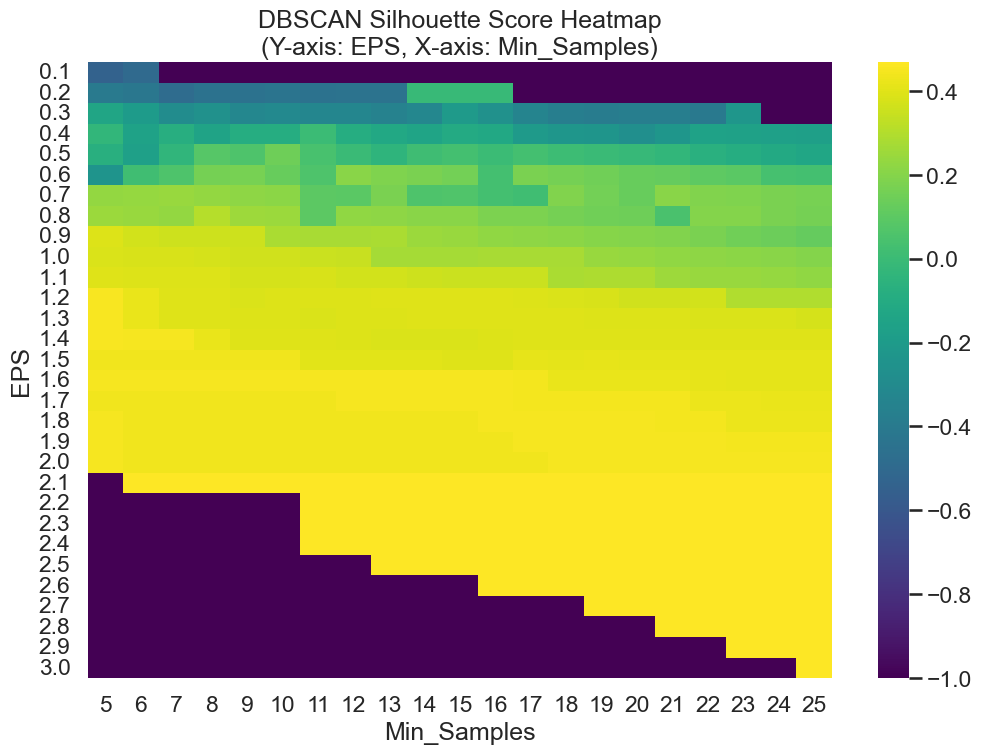

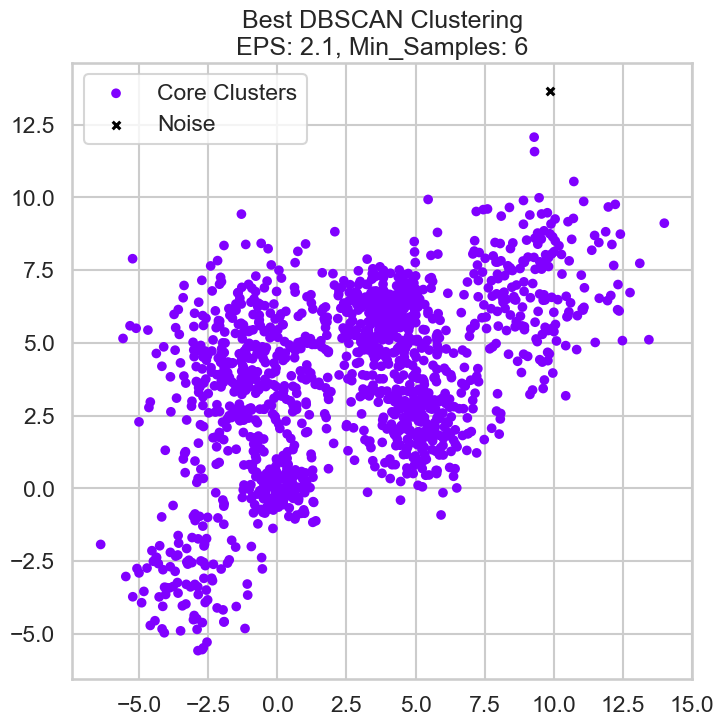

In [17]:
# ---------------------------------------------------------
# DBSCAN Clustering on Multi Blob Data
# ---------------------------------------------------------

# Define the ranges for eps and min_samples
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = range(5, 26)

# We will store the scores in a 2D array for the heatmap
heatmap_scores = np.zeros((len(eps_values), len(min_samples_values)))

best_sil_score_dbscan = -1
best_params_dbscan = {}
best_labels_dbscan = None

print("--- Testing EPS and Min_Samples Combinations ---")

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(Multi_blob_Data)
        
        # Silhouette score requires strictly more than 1 cluster and less than n_samples
        unique_labels = set(labels)
        if len(unique_labels) > 1:
            score = silhouette_score(Multi_blob_Data, labels)
            heatmap_scores[i, j] = score
            
            if score > best_sil_score_dbscan:
                best_sil_score_dbscan = score
                best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
                best_labels_dbscan = labels
        else:
            # If invalid (all noise), assign a default low score for the heatmap
            heatmap_scores[i, j] = -1

print(f"Stored Best DBSCAN Silhouette Score: {best_sil_score_dbscan:.4f} using {best_params_dbscan}")

# --- Plotting Silhouette Score vs EPS and Min_Samples (Heatmap) ---
plt.figure(figsize=(12, 8))
# round the eps values for cleaner axis labels
sns.heatmap(heatmap_scores, xticklabels=list(min_samples_values), 
            yticklabels=np.round(eps_values, 1), cmap='viridis')
plt.title('DBSCAN Silhouette Score Heatmap\n(Y-axis: EPS, X-axis: Min_Samples)')
plt.xlabel('Min_Samples')
plt.ylabel('EPS')
plt.show()

# --- Visualizing the Best Cluster Assignment ---
plt.figure(figsize=(8, 8))
plt.title(f"Best DBSCAN Clustering\nEPS: {best_params_dbscan['eps']:.1f}, Min_Samples: {best_params_dbscan['min_samples']}")

# We don't use the display_cluster helper here because DBSCAN doesn't have 'cluster_centers_'
# Instead, we do a custom scatter, separating core points from noise (-1)
core_mask = best_labels_dbscan != -1
noise_mask = best_labels_dbscan == -1

# Plot core points
plt.scatter(Multi_blob_Data[core_mask, 0], Multi_blob_Data[core_mask, 1], 
            c=best_labels_dbscan[core_mask], cmap='rainbow', s=30, label='Core Clusters')
# Plot noise points in black
plt.scatter(Multi_blob_Data[noise_mask, 0], Multi_blob_Data[noise_mask, 1], 
            c='black', marker='x', s=30, label='Noise')

plt.legend()
plt.show()

In [ ]:

# Parameter Variations: 
# as seen in the heatmap, if eps is too low (0.1) everything is classified as noise because the search radius is too small
# if eps is too high the algorithm merges everything into a single massive cluster
# Similarly, if min_samples is too high it becomes overly strict classifying valid edge points as noise

# Silhouette Score: The silhouette score for DBSCAN behaves uniquely because DBSCAN assigns noise points a label of -1
# The silhouette function treats this -1 group as its own cluster, which lowers the score

# Cluster Shapes: Unlike K-Means that forces circular boundaries, DBSCAN is great at handling weird shapes
# However because our generated blobs overlap so much, DBSCAN merged several adjacent blobs together into a single dense region
# classifying the sparse outer edges as noise (black 'X' in the plot).

In [18]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']

['setosa', 'versicolor', 'virginica']

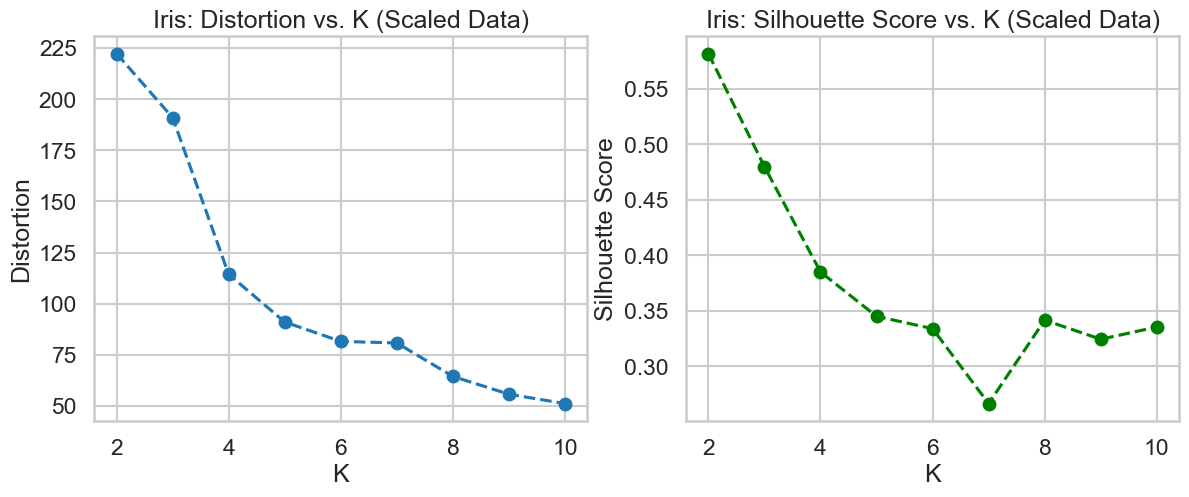

--- Evaluating K=3 (To compare with True Labels) ---
K-Means (K=3) Silhouette Score [UNSCALED]: 0.5512
K-Means (K=3) Silhouette Score [SCALED]: 0.4799


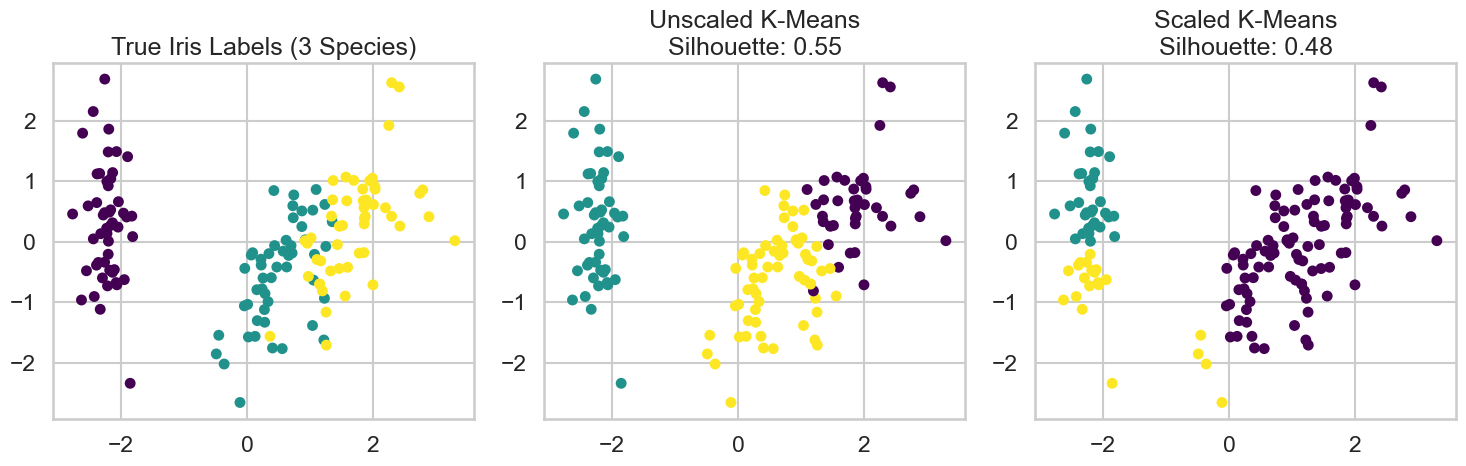

In [21]:
# ---------------------------------------------------------
# Iris Data - K-Means
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_iris = iris_data.data
y_iris = iris_data.target # True labels (0, 1, 2)

# --- Scale the Data ---
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# --- Loop to find the best K ---
k_values_iris = range(2, 11)
distortions_iris = []
silhouette_scores_iris = []

for k in k_values_iris:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_iris_scaled)
    distortions_iris.append(km.inertia_)
    silhouette_scores_iris.append(silhouette_score(X_iris_scaled, labels))

# Plot Elbow and Silhouette for Iris
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values_iris, distortions_iris, marker='o', linestyle='--')
plt.title('Iris: Distortion vs. K (Scaled Data)')
plt.xlabel('K')
plt.ylabel('Distortion')

plt.subplot(1, 2, 2)
plt.plot(k_values_iris, silhouette_scores_iris, marker='o', color='green', linestyle='--')
plt.title('Iris: Silhouette Score vs. K (Scaled Data)')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

# --- Compare Scaled vs Unscaled at K=3 ---
# Even though Silhouette might peak at K=2 we know the true biological data has 3 classes.
print("--- Evaluating K=3 (To compare with True Labels) ---")

km_unscaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_unscaled = km_unscaled.fit_predict(X_iris)
score_unscaled = silhouette_score(X_iris, labels_unscaled)

km_scaled = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels_scaled = km_scaled.fit_predict(X_iris_scaled)
score_scaled = silhouette_score(X_iris_scaled, labels_scaled)

print(f"K-Means (K=3) Silhouette Score [UNSCALED]: {score_unscaled:.4f}")
print(f"K-Means (K=3) Silhouette Score [SCALED]: {score_scaled:.4f}")

# --- Visualization (PCA squashes 4D to 2D for plotting) ---
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, cmap='viridis', s=40)
plt.title('True Iris Labels (3 Species)')

plt.subplot(1, 3, 2)
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_unscaled, cmap='viridis', s=40)
plt.title(f'Unscaled K-Means\nSilhouette: {score_unscaled:.2f}')

plt.subplot(1, 3, 3)
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_scaled, cmap='viridis', s=40)
plt.title(f'Scaled K-Means\nSilhouette: {score_scaled:.2f}')

plt.tight_layout()
plt.show()

In [ ]:

# Finding K: the silhouette score peaks at K=2 rather than K=3 This is because two of the Iris species (Versicolor and Virginica) overlap heavily in their feature dimensions
# making the algorithm mathematically prefer grouping them together
# However, because we know the true labels have 3 species we evaluate K=3

# Effect of Scaling: Scaling slightly lowered the raw Silhouette Score because standardizing alters the distance space
# but scaling is crucial because it prevents features with larger numerical ranges from dominating the distance calculations

# Consistency with Labels: K-Means struggles to perfectly separate the versicolor and virginica species due to their overlap
# Setosa is linearly separable and perfectly clustered
# The colors in the plots do not match perfectly because K-Means arbitrarily assigns cluster IDs (0, 1, 2), but the physical groupings are similar

Agglomerative (K=3) Silhouette Score: 0.4467
Agglomerative (K=3) Adjusted Rand Index: 0.6153

--- Testing DBSCAN on Scaled Iris ---
Best DBSCAN Silhouette Score: 0.5818 using {'eps': np.float64(1.4000000000000004), 'min_samples': 3}
DBSCAN Adjusted Rand Index: 0.5681


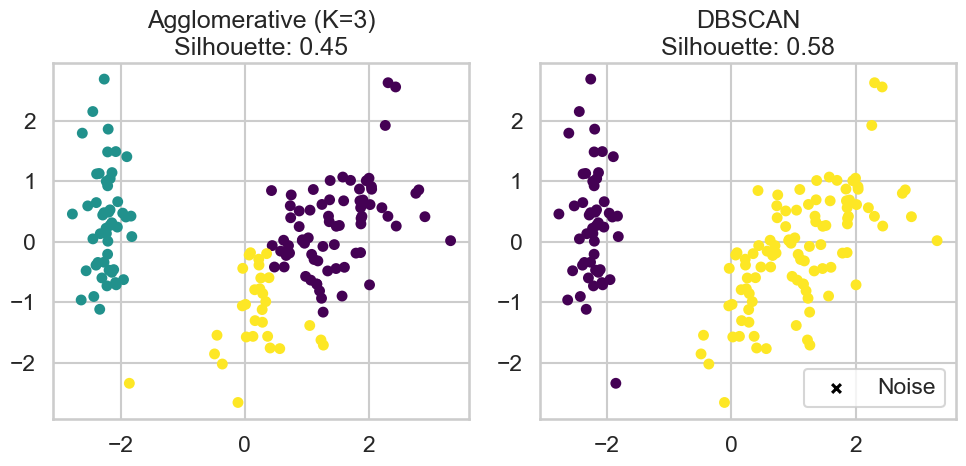

In [23]:
# ---------------------------------------------------------
# Iris Data - Agglomerative & DBSCAN
# ---------------------------------------------------------
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt

# --- Agglomerative Clustering (K=3) ---
agg_iris = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_agg_iris = agg_iris.fit_predict(X_iris_scaled)

score_agg_iris = silhouette_score(X_iris_scaled, labels_agg_iris)
ari_agg_iris = adjusted_rand_score(y_iris, labels_agg_iris)

print(f"Agglomerative (K=3) Silhouette Score: {score_agg_iris:.4f}")
print(f"Agglomerative (K=3) Adjusted Rand Index: {ari_agg_iris:.4f}")

# --- DBSCAN Clustering ---
# Testing a smaller range appropriate for scaled data
eps_values_iris = np.arange(0.3, 1.5, 0.1)
min_samples_values_iris = range(3, 10)

best_sil_score_dbscan_iris = -1
best_params_dbscan_iris = {}
best_labels_dbscan_iris = None

print("\n--- Testing DBSCAN on Scaled Iris ---")
for eps in eps_values_iris:
    for min_samples in min_samples_values_iris:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_iris_scaled)
        
        unique_labels = set(labels)
        # Valid silhouette score needs >1 cluster and <n_samples
        if 1 < len(unique_labels) < len(X_iris_scaled):
            score = silhouette_score(X_iris_scaled, labels)
            if score > best_sil_score_dbscan_iris:
                best_sil_score_dbscan_iris = score
                best_params_dbscan_iris = {'eps': eps, 'min_samples': min_samples}
                best_labels_dbscan_iris = labels

print(f"Best DBSCAN Silhouette Score: {best_sil_score_dbscan_iris:.4f} using {best_params_dbscan_iris}")

# check consistency with true labels for DBSCAN
if best_labels_dbscan_iris is not None:
    ari_dbscan_iris = adjusted_rand_score(y_iris, best_labels_dbscan_iris)
    print(f"DBSCAN Adjusted Rand Index: {ari_dbscan_iris:.4f}")

# --- 3. Visualization ---
plt.figure(figsize=(10, 5))

# Plot 1: Agglomerative
plt.subplot(1, 2, 1)
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_agg_iris, cmap='viridis', s=40)
plt.title(f'Agglomerative (K=3)\nSilhouette: {score_agg_iris:.2f}')

# Plot 2: DBSCAN
plt.subplot(1, 2, 2)
if best_labels_dbscan_iris is not None:
    core_mask_iris = best_labels_dbscan_iris != -1
    noise_mask_iris = best_labels_dbscan_iris == -1
    
    plt.scatter(X_iris_pca[core_mask_iris, 0], X_iris_pca[core_mask_iris, 1], 
                c=best_labels_dbscan_iris[core_mask_iris], cmap='viridis', s=40)
    plt.scatter(X_iris_pca[noise_mask_iris, 0], X_iris_pca[noise_mask_iris, 1], 
                c='black', marker='x', s=40, label='Noise')
    plt.title(f'DBSCAN\nSilhouette: {best_sil_score_dbscan_iris:.2f}')
    plt.legend()
else:
    plt.title('DBSCAN found no valid clusters')

plt.tight_layout()
plt.show()

In [ ]:

# K-Means vs Agglomerative:
# Both K-Means and Agglomerative clustering performed similarly and mapped well to the true labels
# By forcing the data into 3 clusters, they successfully isolated the 'Setosa' class perfectly
# though they both struggled slightly to cleanly divide the overlapping 'Versicolor' and 'Virginica' classes
# This is reflected in a moderate Silhouette Score ~0.45 but a solid Adjusted Rand Index (ARI) of ~0.61

# DBSCAN vs Distance-Based Models:
# DBSCAN behaved very differently on the scaled data
# Its best parameters (eps=1.4, min_samples=3) resulted in finding exactly 2 clusters and 0 noise points
# Because 'Versicolor' and 'Virginica' overlap heavily, DBSCAN's large search radius merged them into one single cluster
# leaving 'Setosa' as the second

# Metric: DBSCAN achieved a higher Silhouette Score (0.58) because 2 well-separated clusters are mathematically "cleaner" than 3 overlapping ones
# However, its ARI (0.56) was lower than Agglomerative (0.61) because it failed to identify the third biological species
# proving that a higher silhouette score doesn't always mean a more contextually accurate model

--- Running K-Means Loop ---


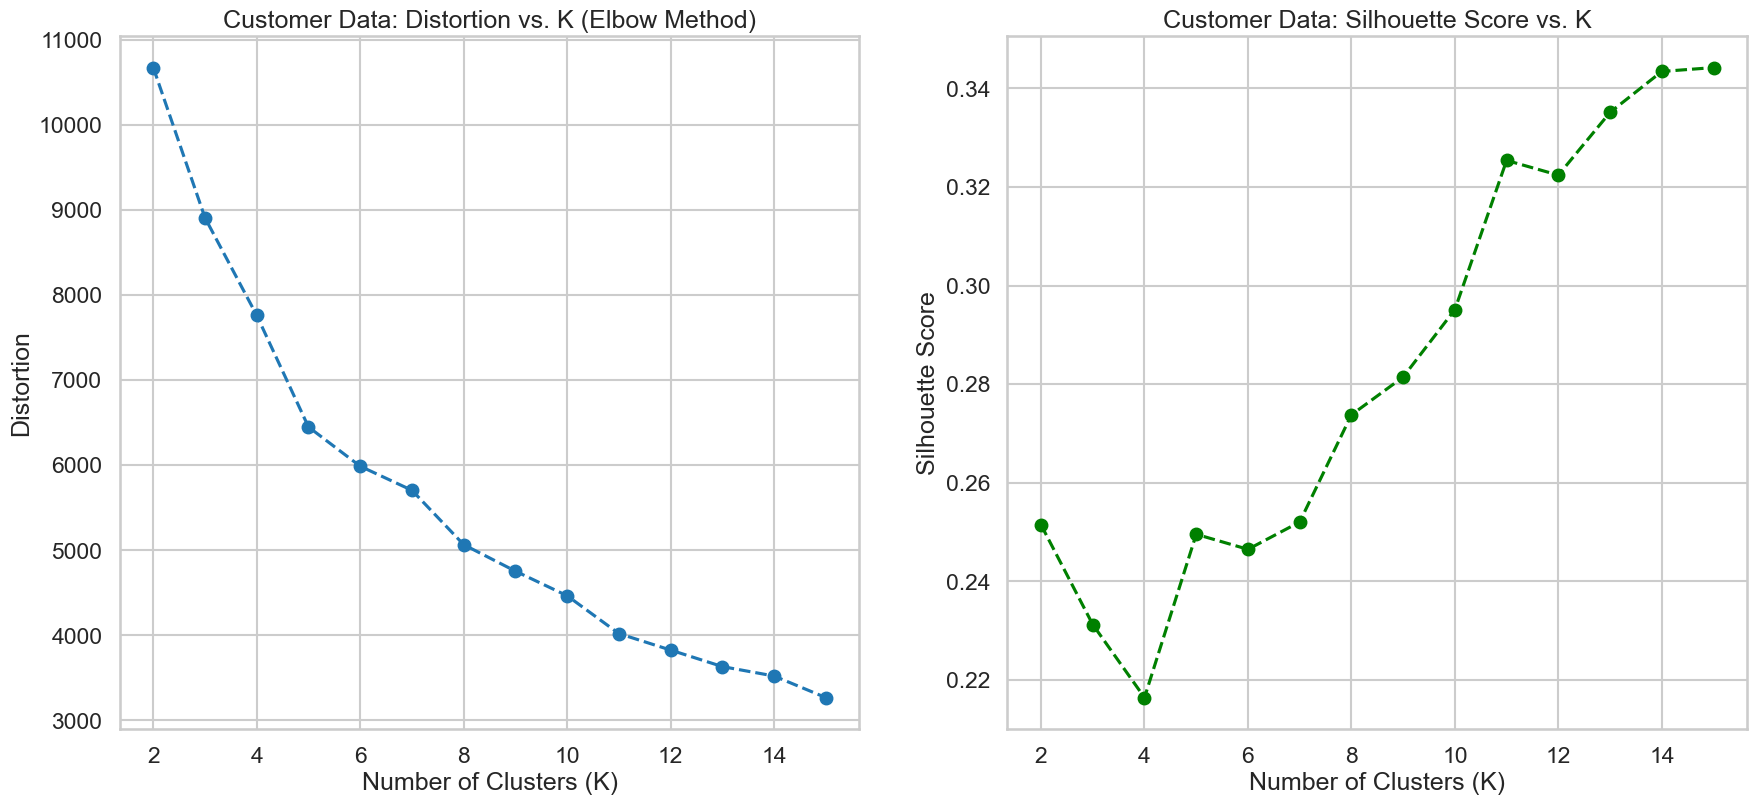


Chosen K-Means (K=8) Silhouette Score: 0.2738


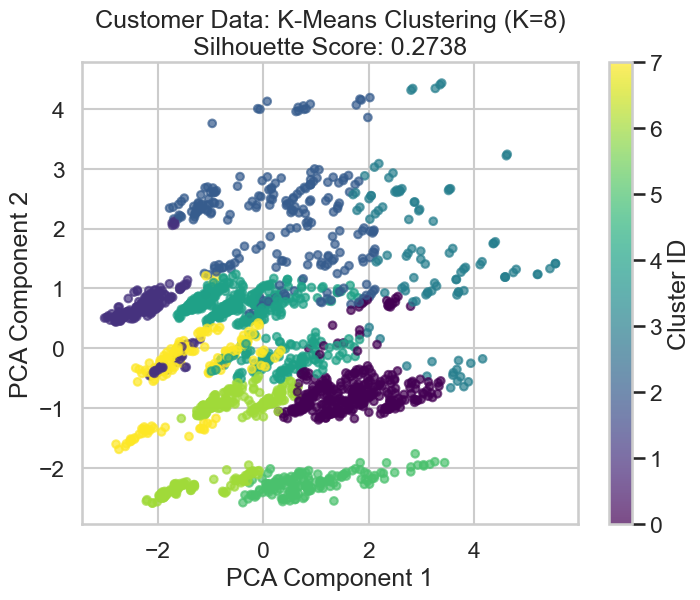

In [38]:
# ---------------------------------------------------------
# Customer Data - K-Means
# ---------------------------------------------------------

# --- Load and Prepare the Data ---
customer_df = pd.read_csv(r'D:\semester 10\[NETW1013] Machine Learning\Clustering Project\GUC_2350_68_65247_2026-02-26T09_19_37\Clustering Project\Customer data.csv')

# Drop the 'ID' column as it has no clustering value
X_customer = customer_df.drop('ID', axis=1)

# Scale the data (Crucial because Income is massively larger than Age or Sex)
scaler_cust = StandardScaler()
X_cust_scaled = scaler_cust.fit_transform(X_customer)

# --- Loop to find the best K ---
k_values_cust = range(2, 16)
distortions_cust = []
silhouette_scores_cust = []

print("--- Running K-Means Loop ---")
for k in k_values_cust:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_cust_scaled)
    distortions_cust.append(km.inertia_)
    silhouette_scores_cust.append(silhouette_score(X_cust_scaled, labels))

# Plot Elbow and Silhouette for Customer Data
plt.figure(figsize=(21, 9))
plt.subplot(1, 2, 1)
plt.plot(k_values_cust, distortions_cust, marker='o', linestyle='--')
plt.title('Customer Data: Distortion vs. K (Elbow Method)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion')

plt.subplot(1, 2, 2)
plt.plot(k_values_cust, silhouette_scores_cust, marker='o', color='green', linestyle='--')
plt.title('Customer Data: Silhouette Score vs. K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# --- Evaluate and Visualize for a Chosen K ---
best_k_cust = 8
km_cust_best = KMeans(n_clusters=best_k_cust, init='k-means++', random_state=42)
labels_cust_best = km_cust_best.fit_predict(X_cust_scaled)
score_cust_best = silhouette_score(X_cust_scaled, labels_cust_best)

print(f"\nChosen K-Means (K={best_k_cust}) Silhouette Score: {score_cust_best:.4f}")

# Visualization (PCA squashes 7D to 2D for plotting)
pca_cust = PCA(n_components=2)
X_cust_pca = pca_cust.fit_transform(X_cust_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_cust_pca[:, 0], X_cust_pca[:, 1], c=labels_cust_best, cmap='viridis', s=30, alpha=0.7)
plt.title(f'Customer Data: K-Means Clustering (K={best_k_cust})\nSilhouette Score: {score_cust_best:.4f}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster ID')
plt.show()

In [ ]:

# Data Preparation: Before clustering, the ID column was dropped because it is an arbitrary identifier that holds no variance or meaning
# Scaling the remaining data with `tandardScaler was strictly required because numerical features like Income
#are orders of magnitude larger than demographic indicators like Age or Sex
# Without scaling, distance-based metrics would be completely dominated by Income alone

# Finding K: The distortion (elbow) curve shows a moderate bend, and the silhouette score shows a localized "bump" around K=8 before steadily rising again for very small micro-clusters
# In the context of business marketing, segmenting customers into 8 distinct groups (young low-income, older high-income, etc) is highly practical
# so K=8 was chosen for evaluation.
# The silhouette score sits around ~0.25, which is typical for dense real-world human demographic data where boundaries blur heavily

--- Generating Dendrogram ---


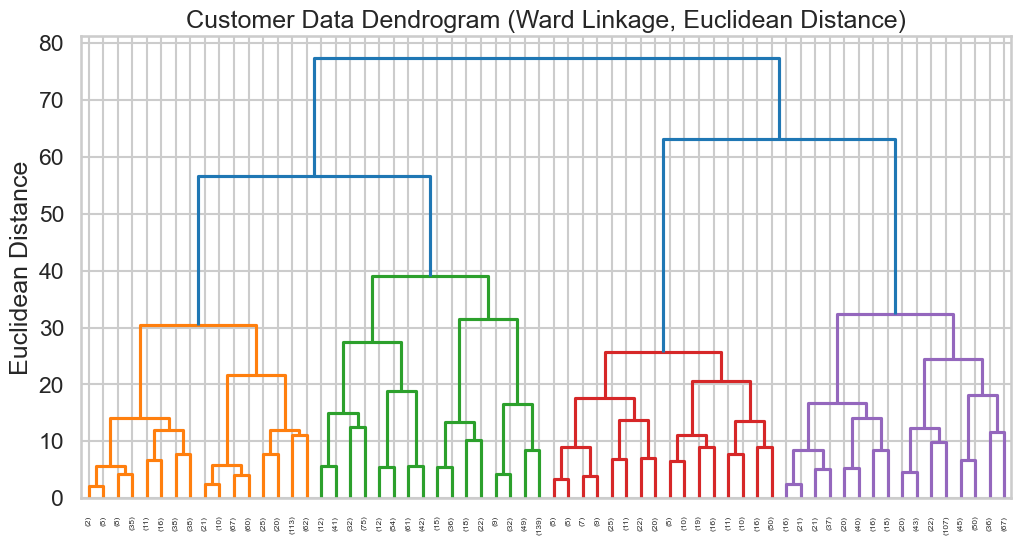

Agglomerative Silhouette Score: 0.2816

--- Running DBSCAN ---
DBSCAN Silhouette Score: 0.3030
DBSCAN found 22 core clusters and 472 noise points.


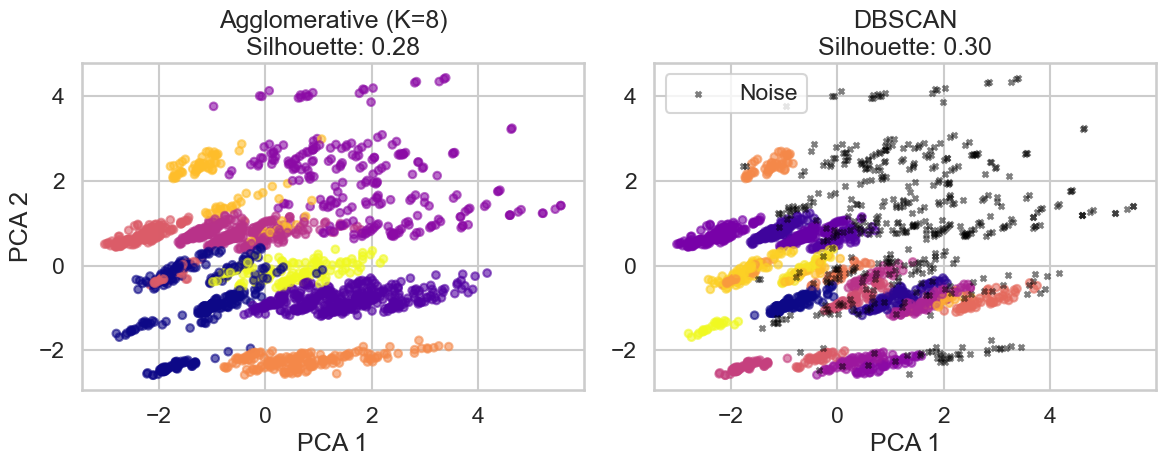

In [44]:
# ---------------------------------------------------------
# Customer Data - Agglomerative & DBSCAN
# ---------------------------------------------------------

# --- Plotting the Dendrogram to decide K ---
print("--- Generating Dendrogram ---")
plt.figure(figsize=(12, 6))
plt.title("Customer Data Dendrogram (Ward Linkage, Euclidean Distance)")

# Create the linkage matrix and plot the dendrogram
Z_cust = shc.linkage(X_cust_scaled, method='ward')
dend_cust = shc.dendrogram(Z_cust, truncate_mode='level', p=5)

plt.ylabel('Euclidean Distance')
plt.show()

# --- Agglomerative Clustering ---
agg_cust = AgglomerativeClustering(n_clusters=8, metric='euclidean', linkage='ward')
labels_agg_cust = agg_cust.fit_predict(X_cust_scaled)
score_agg_cust = silhouette_score(X_cust_scaled, labels_agg_cust)

print(f"Agglomerative Silhouette Score: {score_agg_cust:.4f}")

# --- DBSCAN Clustering ---
print("\n--- Running DBSCAN ---")
db_cust = DBSCAN(eps=0.7, min_samples=14)
labels_db_cust = db_cust.fit_predict(X_cust_scaled)

unique_labels_db = set(labels_db_cust)
if 1 < len(unique_labels_db) < len(X_cust_scaled):
    score_db_cust = silhouette_score(X_cust_scaled, labels_db_cust)
    print(f"DBSCAN Silhouette Score: {score_db_cust:.4f}")
    
    num_clusters_db = len(unique_labels_db) - (1 if -1 in labels_db_cust else 0)
    num_noise_db = list(labels_db_cust).count(-1)
    print(f"DBSCAN found {num_clusters_db} core clusters and {num_noise_db} noise points.")
else:
    print("DBSCAN could not find valid clusters with these parameters.")

# --- Visualization (Agglomerative vs DBSCAN) ---
plt.figure(figsize=(12, 5))

# Plot 1: Agglomerative
plt.subplot(1, 2, 1)
plt.scatter(X_cust_pca[:, 0], X_cust_pca[:, 1], c=labels_agg_cust, cmap='plasma', s=30, alpha=0.6)
plt.title(f'Agglomerative (K=8)\nSilhouette: {score_agg_cust:.2f}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Plot 2: DBSCAN
plt.subplot(1, 2, 2)
core_mask_cust = labels_db_cust != -1
noise_mask_cust = labels_db_cust == -1

plt.scatter(X_cust_pca[core_mask_cust, 0], X_cust_pca[core_mask_cust, 1], 
            c=labels_db_cust[core_mask_cust], cmap='plasma', s=30, alpha=0.6)
plt.scatter(X_cust_pca[noise_mask_cust, 0], X_cust_pca[noise_mask_cust, 1], 
            c='black', marker='x', s=15, alpha=0.5, label='Noise')
plt.title(f'DBSCAN\nSilhouette: {score_db_cust:.2f}')
plt.xlabel('PCA 1')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:

# Unlike the generated blobs or the Iris flowers, the Customer dataset yields lower silhouette scores (~0.28)
# 5 of the 7 features are categorical (Sex, Education, etc.) Euclidean distance naturally struggles to create clean spherical clusters out of categorical features

# Choosing K=8: By analyzing the dendrogram and the elbow/silhouette charts I chose K=8.
# While a smaller K provides broad macro-segments, choosing K=8 allows us to identify more granular specific customer micro-segments.
# The silhouette score of 0.2816 reflects that while there is overlap
# the algorithm successfully forced 100% of the customer base into 8 distinct groups

# Agglomerative vs. DBSCAN: Agglomerative clustering performed well by keeping all data points and grouping them into our requested 8 clusters
# DBSCAN, however, struggled with the categorical density of this dataset
# It fractured the data into 22 tiny core clusters and threw out a massive 472 customers (~25% of the dataset) as noise 

# Metric: DBSCAN achieved a slightly higher Silhouette Score (0.3030) than Agglomerative (0.2816)
# but it did so by literally ignoring the 25% most difficult-to-cluster customers
# In a real-world business scenario, Agglomerative (K=8) is a vastly superior model
# because a business cannot simply ignore a quarter of its customer base or afford to manage 22 separate micro-segments